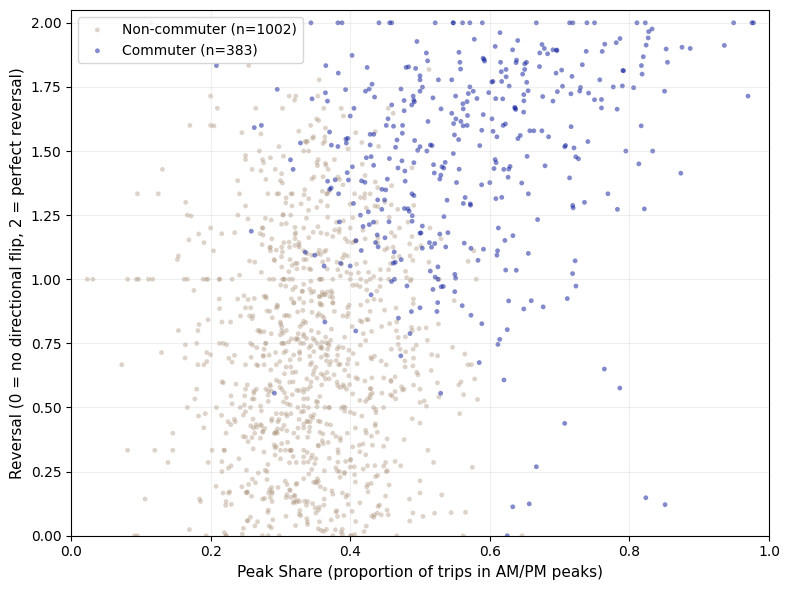

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

cl = pd.read_csv('precovidcommuter_labels.csv')

comm = cl[cl['is_commuter'] == True]
non_comm = cl[cl['is_commuter'] == False]

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(non_comm['peak_share'], non_comm['reversal'],
           s=12, alpha=0.4, color="#ab927a", label=f'Non-commuter (n={len(non_comm)})', edgecolors='none')
ax.scatter(comm['peak_share'], comm['reversal'],
           s=12, alpha=0.5, color="#061798", label=f'Commuter (n={len(comm)})', edgecolors='none')

ax.set_xlabel('Peak Share (proportion of trips in AM/PM peaks)', fontsize=11)
ax.set_ylabel('Reversal (0 = no directional flip, 2 = perfect reversal)', fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 2.05)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('commuter_cluster_scatter.png', dpi=250)
plt.show()

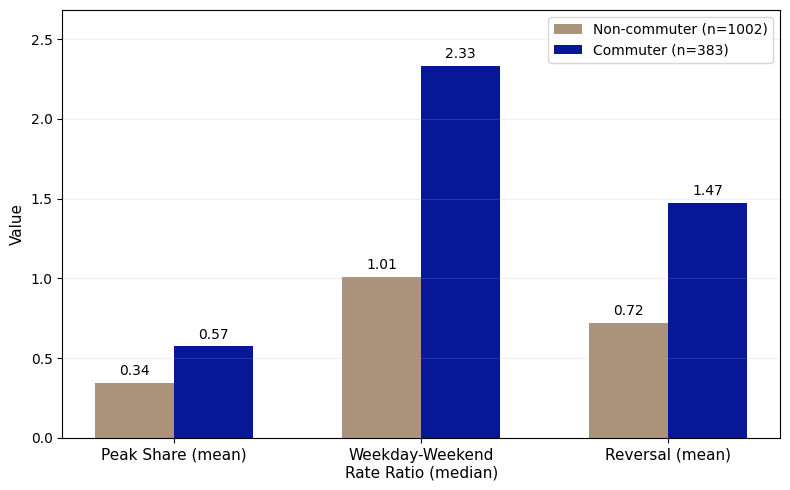

In [3]:
import numpy as np

features = ['Peak Share (mean)', 'Weekday-Weekend\nRate Ratio (median)', 'Reversal (mean)']
commuter_vals = [comm['peak_share'].mean(), comm['weekday_rate_ratio'].median(), comm['reversal'].mean()]
non_commuter_vals = [non_comm['peak_share'].mean(), non_comm['weekday_rate_ratio'].median(), non_comm['reversal'].mean()]

x = np.arange(len(features))
width = 0.32

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, non_commuter_vals, width, color='#ab927a', label=f'Non-commuter (n={len(non_comm)})')
bars2 = ax.bar(x + width/2, commuter_vals, width, color='#061798', label=f'Commuter (n={len(comm)})')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Value', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(features, fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, max(commuter_vals) * 1.15)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('commuter_cluster_bars.png', dpi=250)
plt.show()

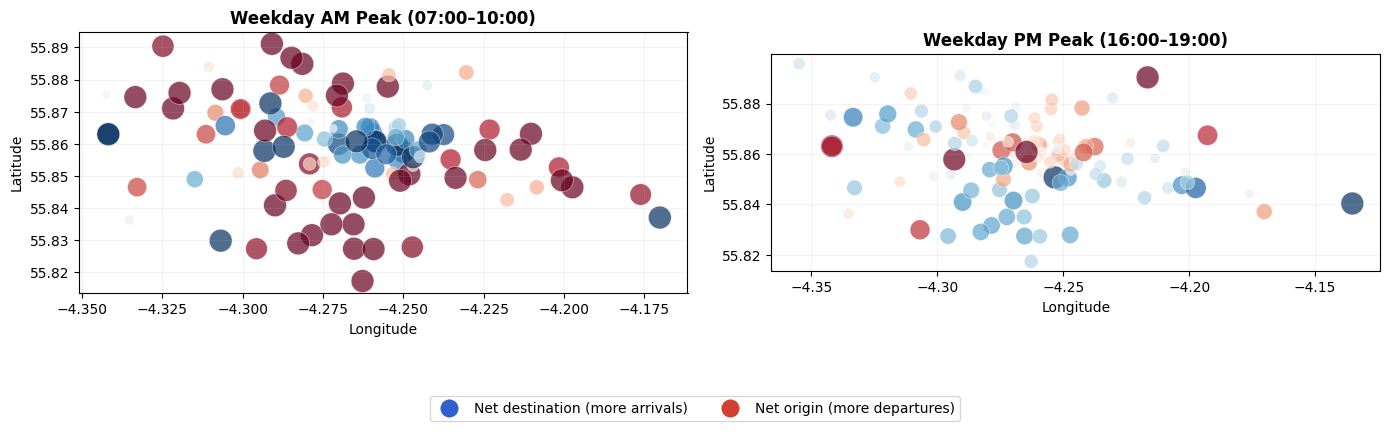

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

df = pd.read_csv('glatrips.csv', usecols=['started_at','origin','destination','start_lat','start_lon'])
df['started_at'] = pd.to_datetime(df['started_at'], utc=True)
df['local'] = df['started_at'].dt.tz_convert('Europe/London')
df['hour'] = df['local'].dt.hour
df['weekday'] = df['local'].dt.dayofweek < 5

station_coords = df.groupby('origin').agg(
    lat=('start_lat','median'), lon=('start_lon','median')
).reset_index().rename(columns={'origin':'station'})

wd = df[df['weekday']].copy()
am = wd[(wd['hour'] >= 7) & (wd['hour'] < 10)]
pm = wd[(wd['hour'] >= 16) & (wd['hour'] < 19)]

def compute_ratio(trips_df, station_coords, min_trips=50):
    origins = trips_df.groupby('origin').size().rename('departures')
    dests = trips_df.groupby('destination').size().rename('arrivals')
    counts = pd.concat([origins, dests], axis=1).fillna(0)
    counts.index.name = 'station'
    counts = counts.reset_index()
    counts['total'] = counts['arrivals'] + counts['departures']
    counts = counts[counts['total'] >= min_trips]
    counts['log_ratio'] = np.log2((counts['arrivals'] + 1) / (counts['departures'] + 1))
    merged = counts.merge(station_coords, on='station')
    return merged

am_stats = compute_ratio(am, station_coords)
pm_stats = compute_ratio(pm, station_coords)

cmap = plt.cm.RdBu
norm = Normalize(vmin=-2, vmax=2)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, data, title in [(axes[0], am_stats, 'AM Peak (07:00–10:00)'),
                         (axes[1], pm_stats, 'PM Peak (16:00–19:00)')]:
    sizes = 30 + np.abs(data['log_ratio'].values.clip(-2, 2)) * 120
    c_vals = data['log_ratio'].values.clip(-2, 2)
    
    ax.scatter(data['lon'], data['lat'], s=sizes, c=c_vals,
               cmap=cmap, norm=norm, alpha=0.7, edgecolors='white', linewidth=0.4)
    ax.set_title(f'Weekday {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=10)
    ax.set_ylabel('Latitude', fontsize=10)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.15)

legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#3060cf', markersize=14,
           label='Net destination (more arrivals)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#cf4030', markersize=14,
           label='Net origin (more departures)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10,
           frameon=True, bbox_to_anchor=(0.5, 0.15))

plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.savefig('station_flow_ratio.png', dpi=250, bbox_inches='tight')
plt.show()

In [5]:
import numpy as np
from scipy.spatial.distance import cdist

def knn_weights(coords, k=5):
    """Binary KNN spatial weights matrix, row-standardised."""
    dist = cdist(coords, coords)
    n = len(coords)
    W = np.zeros((n, n))
    for i in range(n):
        neighbours = np.argsort(dist[i])[1:k+1]
        W[i, neighbours] = 1.0
    row_sums = W.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    W = W / row_sums
    return W

def morans_i(x, W, permutations=999):
    """Global Moran's I with permutation-based p-value."""
    n = len(x)
    z = x - x.mean()
    denom = (z ** 2).sum()
    numer = (z[:, None] * z[None, :] * W).sum()
    I = (n / W.sum()) * (numer / denom)
    
    I_perm = np.zeros(permutations)
    rng = np.random.default_rng(42)
    for p in range(permutations):
        z_shuf = rng.permutation(z)
        num_p = (z_shuf[:, None] * z_shuf[None, :] * W).sum()
        I_perm[p] = (n / W.sum()) * (num_p / denom)
    
    p_value = (np.abs(I_perm) >= np.abs(I)).mean()
    return I, p_value

# Assuming am_stats and pm_stats are already computed
for label, data in [('AM Peak', am_stats), ('PM Peak', pm_stats)]:
    coords = data[['lat','lon']].values
    W = knn_weights(coords, k=5)
    I, p = morans_i(data['log_ratio'].values, W)
    print(f"{label}: Moran's I = {I:.4f}, p = {p:.4f} (n={len(data)})")

AM Peak: Moran's I = 0.4338, p = 0.0000 (n=107)
PM Peak: Moran's I = 0.1994, p = 0.0000 (n=114)


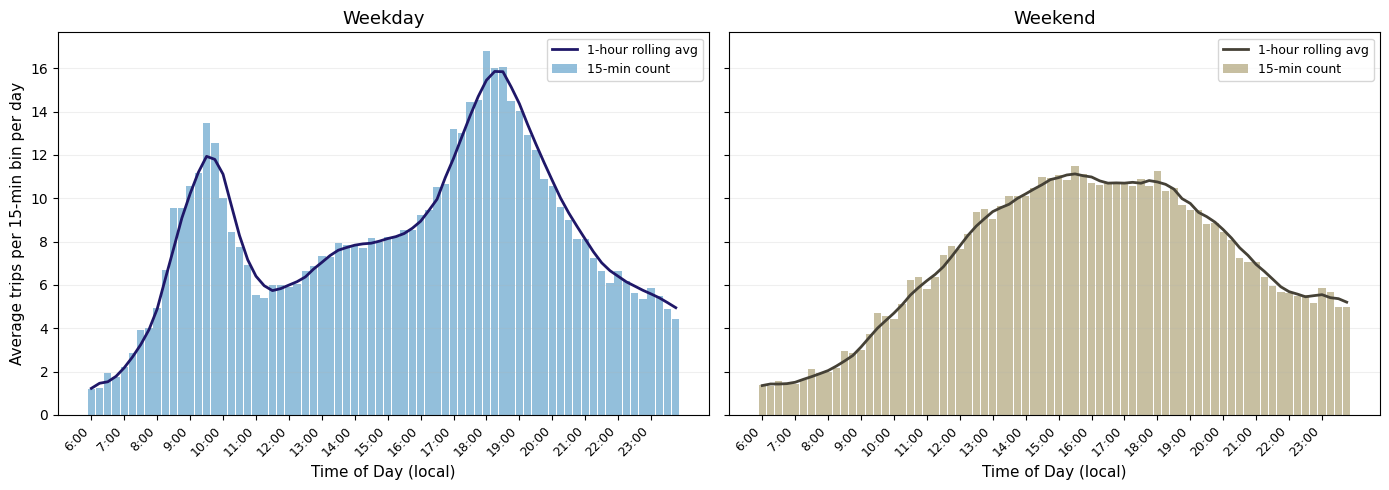

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('glaalltrips.csv', usecols=['started_at'])
df['started_at'] = pd.to_datetime(df['started_at'], utc=True)

# Convert to local Glasgow time
df['local'] = df['started_at'].dt.tz_convert('Europe/London')
df['hour'] = df['local'].dt.hour
df['minute'] = df['local'].dt.minute
df['weekday'] = df['local'].dt.dayofweek < 5

# Filter to 6am - midnight
df = df[(df['hour'] >= 6) & (df['hour'] < 24)]

# 15-minute bins: bin index = (hour - 6) * 4 + minute // 15
df['bin'] = (df['hour'] - 6) * 4 + df['minute'] // 15

wd = df[df['weekday']].groupby('bin').size()
we = df[~df['weekday']].groupby('bin').size()

# Normalise to per-day average
n_wd_days = df[df['weekday']]['local'].dt.date.nunique()
n_we_days = df[~df['weekday']]['local'].dt.date.nunique()
wd_rate = wd / n_wd_days
we_rate = we / n_we_days

# Full bin range
bins = np.arange(0, (24 - 6) * 4)  # 72 bins from 6am to midnight
wd_rate = wd_rate.reindex(bins, fill_value=0)
we_rate = we_rate.reindex(bins, fill_value=0)

# Rolling average (window = 4 bins = 1 hour)
wd_rolling = wd_rate.rolling(4, center=True, min_periods=1).mean()
we_rolling = we_rate.rolling(4, center=True, min_periods=1).mean()

# X-axis labels
tick_positions = np.arange(0, len(bins), 4)  # every hour
tick_labels = [f'{h}:00' for h in range(6, 24)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Weekday
axes[0].bar(bins, wd_rate, color='#2980b9', alpha=0.5, width=0.9, label='15-min count')
axes[0].plot(bins, wd_rolling, color="#1f1768", linewidth=2, label='1-hour rolling avg')
axes[0].set_title('Weekday', fontsize=13)
axes[0].set_xlabel('Time of Day (local)', fontsize=11)
axes[0].set_ylabel('Average trips per 15-min bin per day', fontsize=11)
axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=9)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.2)

# Weekend
axes[1].bar(bins, we_rate, color="#918045", alpha=0.5, width=0.9, label='15-min count')
axes[1].plot(bins, we_rolling, color="#454136", linewidth=2, label='1-hour rolling avg')
axes[1].set_title('Weekend', fontsize=13)
axes[1].set_xlabel('Time of Day (local)', fontsize=11)
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=9)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('trip_time_profile.png', dpi=250)
plt.show()

C:\Users\Calum\AppData\Local\Temp\ipykernel_34452\500714261.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  covidvis['month'] = covidvis['local'].dt.to_period('M')


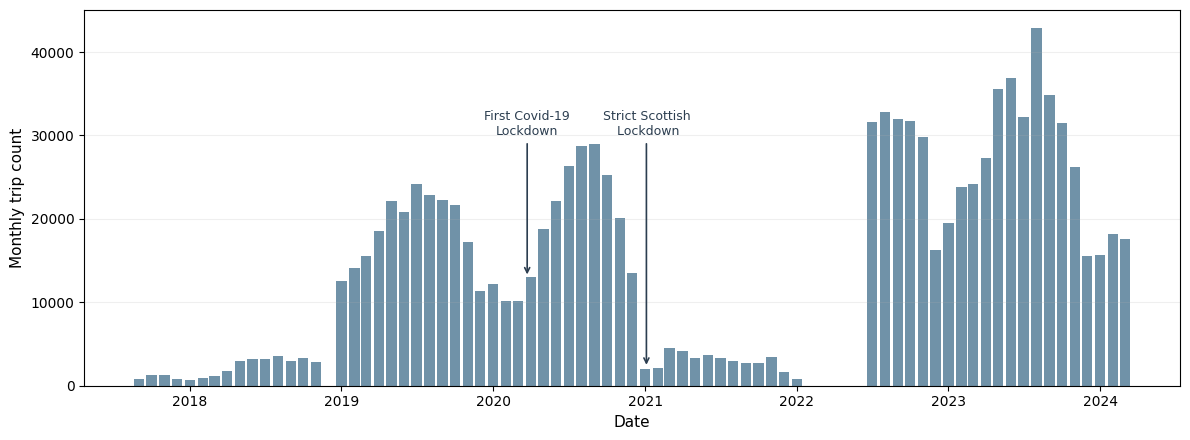

In [9]:
covidvis = pd.read_csv('glatrips.csv', usecols=['started_at'])
covidvis['started_at'] = pd.to_datetime(df['started_at'], utc=True)
covidvis['local'] = covidvis['started_at'].dt.tz_convert('Europe/London')
covidvis['month'] = covidvis['local'].dt.to_period('M')

monthly = covidvis.groupby('month').size()
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(monthly.index, monthly.values, width=25, color="#346484", alpha=0.7)

events = [
    (pd.Timestamp('2020-03-23'), 'First Covid-19\nLockdown', -0.15),
     (pd.Timestamp('2021-01-04'), 'Strict Scottish\n Lockdown', -0.15)
    ]
for date, label, offset in events:
    ypos = monthly.loc[monthly.index >= date].iloc[0] if date <= monthly.index.max() else 0
    ax.annotate(label, xy=(date, ypos), xytext=(date, monthly.max() * (0.85 + offset)),
                arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=1.2),
                fontsize=9, ha='center', color='#2c3e50')

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Monthly trip count', fontsize=11)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('monthly_trips_timeline.png', dpi=250)
plt.show()

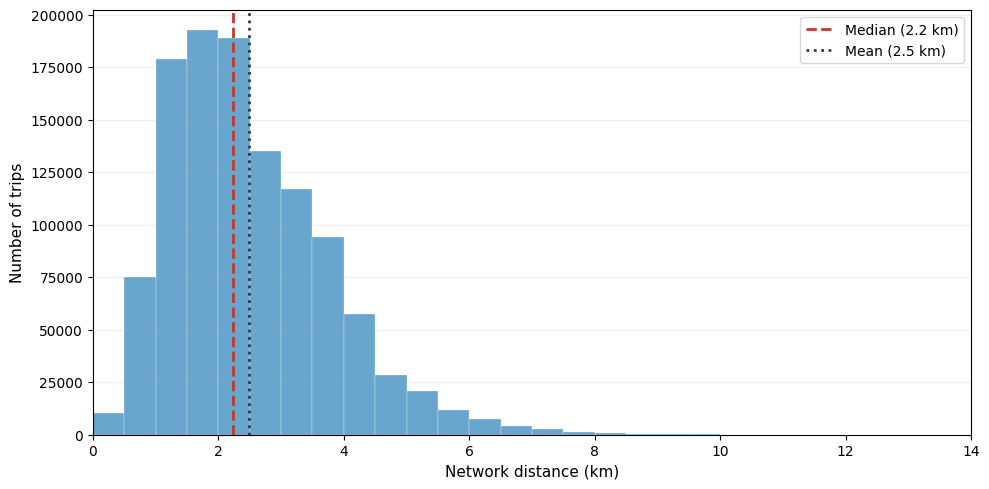

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

twm = pd.read_csv('glasgow_exposure_twm.csv')

# Recover network route length from exposure: route_length = len_any / exp_any
mask = twm['exp_any'] > 0
twm.loc[mask, 'route_km'] = twm.loc[mask, 'len_any_m'] / twm.loc[mask, 'exp_any'] / 1000

data = twm.loc[mask, ['route_km', 'trips']].copy()
weights = data['trips'].values
distances = data['route_km'].values

# Weighted stats
weighted_mean = np.average(distances, weights=weights)
sorted_idx = np.argsort(distances)
cum_weights = np.cumsum(weights[sorted_idx])
weighted_median = distances[sorted_idx][np.searchsorted(cum_weights, cum_weights[-1] * 0.5)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(distances, bins=np.arange(0, 15.5, 0.5), weights=weights, color='#2980b9',
        alpha=0.7, edgecolor='white', linewidth=0.3)
ax.axvline(weighted_median, color='#c0392b', linewidth=2, linestyle='--',
           label=f'Median ({weighted_median:.1f} km)')
ax.axvline(weighted_mean, color='#2c3e50', linewidth=2, linestyle=':',
           label=f'Mean ({weighted_mean:.1f} km)')
ax.set_xlabel('Network distance (km)', fontsize=11)
ax.set_ylabel('Number of trips', fontsize=11)
ax.legend(fontsize=10)
ax.set_xlim(0, 14)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('trip_network_distance.png', dpi=250)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib import cm

# ---- paths (edit to match your local layout) ----
STATIONS_PATH  = "glasgow_stations.csv"
DATAZONES_PATH = "CensusData/DZshp/OutputArea2022_MHW/OutputArea2022_MHW.shp"
DZ_ID_FIELD    = "code"
BUFFER_M       = 250

# ---- load and reproject ----
stations = pd.read_csv(STATIONS_PATH)
stations = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(stations["lon"], stations["lat"]),
    crs="EPSG:4326",
).to_crs(epsg=27700)

datazones = gpd.read_file(DATAZONES_PATH).to_crs(epsg=27700)

# ---- assign datazones to station buffers (centroid-in-buffer) ----
station_buffers = stations[["station_id", "geometry"]].copy()
station_buffers["geometry"] = station_buffers.geometry.buffer(BUFFER_M)

datazones = datazones[[DZ_ID_FIELD, "geometry"]].copy()

matches = gpd.sjoin(
    datazones, station_buffers,
    predicate="intersects", how="inner",
)

# count: how many unique stations does each datazone fall within?
counts = matches.groupby(DZ_ID_FIELD)["station_id"].nunique().rename("n_stations")

# limit the map to only datazones that appear in at least one buffer
plot_gdf = datazones[datazones[DZ_ID_FIELD].isin(counts.index)].copy()
plot_gdf = plot_gdf.merge(counts, left_on=DZ_ID_FIELD, right_index=True, how="left")

# ---- colour scheme: discrete integer bins ----
max_count = int(plot_gdf["n_stations"].max())
boundaries = np.arange(0.5, max_count + 1.5, 1)   # 0.5, 1.5, 2.5 ... centres on integers
tick_labels = list(range(1, max_count + 1))

cmap = cm.get_cmap("YlOrRd", max_count)
norm = BoundaryNorm(boundaries, cmap.N)

# ---- plot ----
fig, ax = plt.subplots(figsize=(10, 10))

plot_gdf.plot(
    column="n_stations", cmap=cmap, norm=norm,
    linewidth=0.15, edgecolor="grey",
    legend=True, ax=ax,
    legend_kwds={
        "label": "Number of station buffers (250 m)",
        "shrink": 0.45,
        "ticks": tick_labels,
    },
)

# overlay station points
stations.plot(ax=ax, color="black", markersize=2.5, zorder=5)

ax.set_axis_off()
ax.set_title(
    "Census Output Areas by Number of Overlapping Station Buffers (250 m)",
    fontsize=13, pad=12,
)
plt.tight_layout()
plt.savefig("station_overlap_250m.png", dpi=300, bbox_inches="tight")
plt.close(fig)

# ---- summary stats for the write-up ----
print(f"Output areas within at least one 250m buffer: {len(counts)}")
print(f"Max station overlap for a single output area:  {max_count}")
print(f"\nDistribution of overlap counts:")
print(counts.value_counts().sort_index().to_string())

# ---- flag station pairs with identical datazone sets ----
pair_sets = (
    matches.groupby("station_id")[DZ_ID_FIELD]
    .apply(lambda x: frozenset(x))
    .reset_index()
)
pair_sets.columns = ["station_id", "dz_set"]

dupes = pair_sets.groupby("dz_set")["station_id"].apply(list).reset_index()
dupes = dupes[dupes["station_id"].apply(len) > 1]

if len(dupes) > 0:
    print(f"\nStation pairs sharing IDENTICAL output area sets at {BUFFER_M}m:")
    for _, row in dupes.iterrows():
        print(f"  {row['station_id']}  ({len(row['dz_set'])} shared datazones)")
else:
    print(f"\nNo stations share identical output area sets at {BUFFER_M}m.")

print("\nSaved: station_overlap_250m.png")

C:\Users\Calum\AppData\Local\Temp\ipykernel_39476\1363396168.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlOrRd", max_count)


Output areas within at least one 250m buffer: 1440
Max station overlap for a single output area:  16

Distribution of overlap counts:
n_stations
1     1012
2      307
3       71
4       26
5       12
6        6
7        2
8        1
11       1
12       1
16       1

Station pairs sharing IDENTICAL output area sets at 250m:
  ['Queen Elizabeth University Hospital', 'University Hospital, Queen Eliza']  (2 shared datazones)
  ['Paisley Road Toll', 'Paisley Road Toll - ELECTRIC']  (14 shared datazones)
  ['Sheilds Road', 'Shields Road']  (20 shared datazones)
  ['Glasgow Science Centre', 'Scottish Event Campus (formerly S.E.C.C)']  (2 shared datazones)

Saved: station_overlap_250m.png


C:\Users\Calum\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\geopandas\plotting.py:940: UserWarning: Mismatched number of handles and labels: len(handles) = 5 len(labels) = 61
  ax.legend(**legend_kwds)


TypeError: Legend.__init__() got an unexpected keyword argument 'shrink'

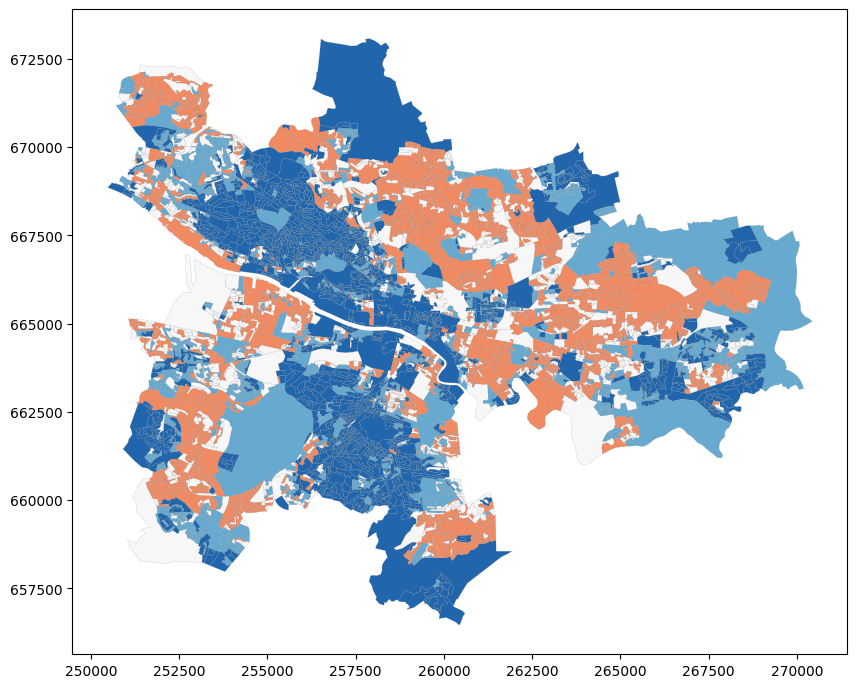

In [8]:
import re
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap

# ---- load ----
nssec = pd.read_csv("CensusData/Ns_SeC.csv", skiprows=3)
nssec = nssec.rename(columns={nssec.columns[0]: "Datazone"})
nssec = nssec[nssec["Datazone"].astype(str).str.match(r"^S00\d+$")]
l_cols = [c for c in nssec.columns if c.startswith("L")]
for c in l_cols:
    nssec[c] = pd.to_numeric(nssec[c].replace("-", 0), errors="coerce")

# score each column by its L-number, exclude L15 (students)
scores = {}
for c in l_cols:
    num = int(re.match(r"L(\d+)", c).group(1))
    if num != 15:
        scores[c] = num

nssec["nssec_weighted"] = sum(nssec[c] * v for c, v in scores.items())
nssec["nssec_denom"] = sum(nssec[c] for c in scores)
nssec["avg_nssec"] = nssec["nssec_weighted"] / nssec["nssec_denom"]
nssec = nssec[["Datazone", "avg_nssec"]].dropna()

# ---- quintiles ----
nssec["quintile"] = pd.qcut(nssec["avg_nssec"], 5, labels=[1, 2, 3, 4, 5])

# ---- map ----
datazones = gpd.read_file(
    "CensusData/DZshp/OutputArea2022_MHW/OutputArea2022_MHW.shp"
).to_crs(epsg=27700)

gla_codes = set(pd.read_csv("CensusData/GlaWorkplacePop.csv")["OutputCode"])
datazones = datazones[datazones["code"].isin(gla_codes)]

plot_gdf = datazones.merge(nssec, left_on="code", right_on="Datazone", how="inner")

cmap = ListedColormap(["#2166ac", "#67a9cf", "#f7f7f7", "#ef8a62", "#b2182b"])
norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5, 5.5], cmap.N)

fig, ax = plt.subplots(figsize=(10, 10))
plot_gdf.plot(
    column="quintile", cmap=cmap, norm=norm,
    linewidth=0.1, edgecolor="grey",
    legend=True, ax=ax,
    legend_kwds={"labels": "NS-SeC Score Quintile (1 = least deprived, 5 = most deprived)",
                 "shrink": 0.45, "ticks": [1, 2, 3, 4, 5]},
)
ax.set_axis_off()
ax.set_title("NS-SeC Weighted Score by Output Area — Glasgow", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("nssec_quintile_map.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Output areas mapped: {len(plot_gdf)}")
print(f"\nQuintile boundaries:")
print(pd.qcut(nssec["avg_nssec"], 5).value_counts().sort_index())